In [ ]:
import numpy as np

from tools.surface_code import generate_steane_circuit 
from tools.error_models import construct_circuit_noise_model 
from tools.analysis import generate_log_error_rates, gen_error_model_count_logical_error_MWPM, count_logical_errors_using_ML_FT 

In [2]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/new_start/tools/graphics.py'>

In [25]:
#ML (Basic Noise)
distances = [3,5]
reps = 1
noise_set = np.logspace(-3,-0.9, num=15)
# ML

steane_circuits = [generate_steane_circuit(d,rounds=reps) for d in distances]
noise_func = construct_circuit_noise_model


In [30]:
# ML
num_shots = 10_000
count_logical_func = count_logical_errors_using_ML_FT

log_error_rates_ML, y_errs_ML = generate_log_error_rates(
    steane_circuits,
    noise_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

In [26]:
# MWPM
num_shots = 100_000
count_logical_func = gen_error_model_count_logical_error_MWPM("circ_lvl")


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates(
    steane_circuits,
    noise_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

<Figure size 640x480 with 0 Axes>

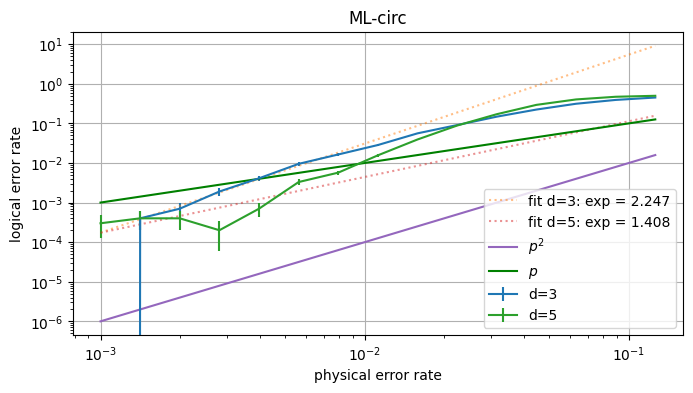

<Figure size 640x480 with 0 Axes>

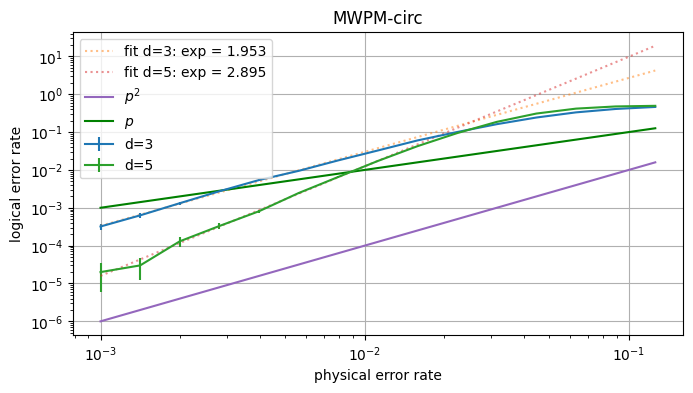

In [32]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML-circ"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM-circ"
    ) 